In [1]:
import numpy as np
import stim
import torch
import pymatching
from collections import OrderedDict
from sklearn.model_selection import train_test_split
from torch import nn, optim
from torch.utils.data import Dataset, DataLoader, Subset

print(stim.__version__)

1.16.0


In [48]:
#Surface code stabilizer circuit

circuit = stim.Circuit.generated(
    "surface_code:rotated_memory_z", # Protect a qubit stored in the z basis to detect a bit flip (logical x error)
    rounds=9,
    distance=3,
    #after_clifford_depolarization=0.005, # Circuit-level (FT) noise
    #after_reset_flip_probability=0.005, # Circuit-level (FT) noise
    before_measure_flip_probability=0.005,#flip on ancilla measurement
    before_round_data_depolarization=0.005 #uniform X,Y,Z error 
)

#samples detector = XOR(ancilla_last_round, ancilla_this_round) for each ancilla measurement
sampler = circuit.compile_detector_sampler(seed=42) #Set a seed so that things are predictable


In [49]:
# Measuring the stabilizers x- and z-ancillas. 
# Generating the samples to train the MLP decoder

n_shots = 1_000_000
# syndromes are the detector outcomes ;-) 1*10**6 x 72 : 8 ancilla (cuz d^2-1 from euler formula) for 9 rounds of measurements
# obs did the bit really flipped? 1*10**6 x 1 : 1 logical qubit
syndromes, obs = sampler.sample(shots=n_shots, separate_observables=True)

# Seeing the fraction that has 1 values
print(f"Mean of the syndromes (detector): {np.mean(syndromes)}")
print(f"Mean of the observables (logical qubit): {np.mean(obs)}")
# Converting to numerical numbers for computations 
labels = obs.astype(np.float32)
features = syndromes.astype(np.float32)
print(labels.shape)
print(len(features))
# From numpy to torch
labels = torch.from_numpy(labels)
features = torch.from_numpy(features)

Mean of the syndromes (detector): 0.019452638888888887
Mean of the observables (logical qubit): 0.095258
(1000000, 1)
1000000


In [50]:
# Baseline MWPM decoder (pymatching)
# Our decoder will be compared to this later on

dem = circuit.detector_error_model(decompose_errors=True)
matcher = pymatching.Matching.from_detector_error_model(dem)

preds = matcher.decode_batch(syndromes)

print(preds[90])
# Count the mistakes.
num_errors = 0
for shot in range(n_shots):
    actual_for_shot = obs[shot]
    predicted_for_shot = preds[shot]
    if not np.array_equal(actual_for_shot, predicted_for_shot):
        num_errors += 1
print(num_errors)
print(f'LER = {num_errors/n_shots:.2%}')

[0]
5835
LER = 0.58%


In [51]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("using device:", device)


using device: cuda


In [52]:
# Dataset from syndromes measurement and logical observables

class quantum_dataset(Dataset):
    def __init__(self):
        self.features = features
        self.labels = labels
    def __len__(self):
        return len(self.features)
    def __getitem__(self, id):
        return self.features[id], self.labels[id]

dataset = quantum_dataset()

if device.type == "cuda":
    BATCH_SIZE = 1024
else : 
    BATCH_SIZE = 128
print(f"Batch size: {BATCH_SIZE}")
indices = np.arange(len(dataset))
train_indices, test_indices = train_test_split(
    indices,
    test_size=0.2,
    random_state=42,
    stratify=dataset.labels.numpy()
)

train_dataset = Subset(dataset, train_indices)
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)
test_dataset = Subset(dataset, test_indices)
test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

Batch size: 1024


In [87]:
# Neural Network Model
input_size = 72 # N_rounds = 9, N_ancillas = 8 (for distance=3)
output_size = 1
hidden_sizes = (256, 128, 64)
dropout_p = .1
# set to be able to compare models
torch.manual_seed(42)
model = nn.Sequential(OrderedDict([
                      ('fc1', nn.Linear(input_size, hidden_sizes[0])),
                      ('relu1', nn.ReLU()),
                      ('drp1', nn.Dropout(dropout_p)),
                      ('fc2', nn.Linear(hidden_sizes[0], hidden_sizes[1])),
                      ('relu2', nn.ReLU()),
                      ('drp2', nn.Dropout(dropout_p)),
                      ('fc3', nn.Linear(hidden_sizes[1], hidden_sizes[2])),
                      ('relu3', nn.ReLU()),
                      ('drp3', nn.Dropout(dropout_p)),
                      ('fc4', nn.Linear(hidden_sizes[2], output_size)),
                      ])
                    )
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=0.003) #It was 0.01
model = model.to(device)

In [88]:
# sanity check
synds, labs = next(iter(train_loader))
ind = 45
model.eval()
x = synds[ind].unsqueeze(0).to(device)  
o = model(x)
print(o.item(), torch.sigmoid(o).item())
print(labs.shape)
print(synds.size(0))
model.train()

0.11226478219032288 0.5280367136001587
torch.Size([1024, 1])
1024


Sequential(
  (fc1): Linear(in_features=72, out_features=256, bias=True)
  (relu1): ReLU()
  (drp1): Dropout(p=0.1, inplace=False)
  (fc2): Linear(in_features=256, out_features=128, bias=True)
  (relu2): ReLU()
  (drp2): Dropout(p=0.1, inplace=False)
  (fc3): Linear(in_features=128, out_features=64, bias=True)
  (relu3): ReLU()
  (drp3): Dropout(p=0.1, inplace=False)
  (fc4): Linear(in_features=64, out_features=1, bias=True)
)

In [89]:
# Training our MLP decoder

epochs = 50
test_losses = []
train_losses = []
acc = 0.0
saved_epoch = 1
for e in range(epochs):
    train_l = 0
    for x_train, y_train in train_loader:
        y_train = y_train.view(-1, 1).float().to(device)
        x_train = x_train.to(device)

        optimizer.zero_grad()
        loss = criterion(model(x_train), y_train)
        loss.backward()

        optimizer.step()

        train_l += loss.item()
    else:#Note : not useful since no break in previous for

        with torch.no_grad():
            model.eval()
            test_l = 0
            total_s = 0
            correct = 0

            for x_train, y_train in test_loader:
                y_train = y_train.view(-1, 1).float().to(device)
                x_train = x_train.to(device)
                
                logits = model(x_train)
                loss = criterion(logits, y_train)

                # Binary prediction: logit > 0 corresponds to sigmoid(logit) > 0.5
                preds = (logits > 0.0).float()
                correct += (preds == y_train).sum().item()
  
                total_s += x_train.size(0)
                test_l += loss.item()

            model.train()

    train_losses.append(train_l/len(train_loader))
    test_losses.append(test_l/len(test_loader))
    t_acc = correct/total_s

    if t_acc > acc:
        acc = t_acc
        saved_epoch = e + 1
        torch.save(model.state_dict(), 'ch_point.pth')
    print(f"Epoch {e+1}/{epochs}: -*-*-*-*-*-")
    print(f"Training Loss = {train_l/len(train_loader)}")
    print(f"Validation Loss = {test_l/len(test_loader)}")
    print(f"Accuracy = {correct/total_s}")

print(f"Highest accuracy: {acc:.2f}")


Epoch 1/50: -*-*-*-*-*-
Training Loss = 0.06577909598662934
Validation Loss = 0.023195009685729687
Accuracy = 0.99315
Epoch 2/50: -*-*-*-*-*-
Training Loss = 0.022402899037889393
Validation Loss = 0.019768445567246908
Accuracy = 0.994135
Epoch 3/50: -*-*-*-*-*-
Training Loss = 0.01959848872152493
Validation Loss = 0.0182760703681531
Accuracy = 0.994505
Epoch 4/50: -*-*-*-*-*-
Training Loss = 0.017971953018056347
Validation Loss = 0.017607338301248242
Accuracy = 0.99483
Epoch 5/50: -*-*-*-*-*-
Training Loss = 0.017486836448611924
Validation Loss = 0.017525552831381103
Accuracy = 0.99489
Epoch 6/50: -*-*-*-*-*-
Training Loss = 0.016724558910676528
Validation Loss = 0.017202425386984736
Accuracy = 0.99492
Epoch 7/50: -*-*-*-*-*-
Training Loss = 0.01589809199396159
Validation Loss = 0.01723153663476055
Accuracy = 0.99494
Epoch 8/50: -*-*-*-*-*-
Training Loss = 0.01563529304259688
Validation Loss = 0.016890649056556274
Accuracy = 0.995
Epoch 9/50: -*-*-*-*-*-
Training Loss = 0.0153570107792

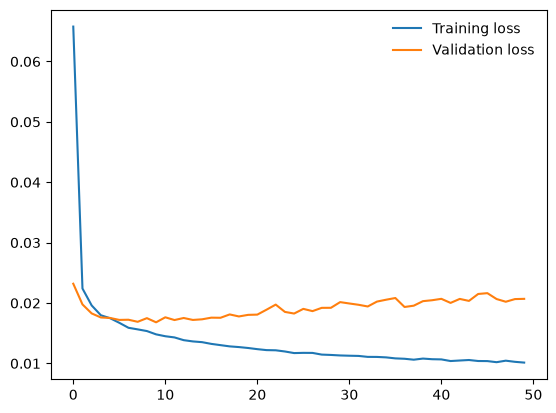

In [90]:
# Trained for 651min ~ 10hr51min. This was 50 epochs
import matplotlib.pyplot as plt
plt.plot(train_losses, label='Training loss')
plt.plot(test_losses, label='Validation loss')

plt.legend(frameon=False)

In [91]:
state_dict = torch.load('ch_point.pth')
model.load_state_dict(state_dict)

<All keys matched successfully>

In [92]:
f, l = next(iter(train_loader))
f = f.to(device)
l = l.to(device)

model.eval()
with torch.no_grad():
    logits = model(f)
    pred = (logits > 0).float()
    pred = pred.view_as(l)

print(pred.shape)
print((l == pred).sum().item())

torch.Size([1024, 1])
1020


# Evaluating Model

In [93]:
# Create a fresh, unseen evaluation dataset from independent samples
n_eval_shots = 200_000
eval_syndromes, eval_obs = sampler.sample(shots=n_eval_shots, separate_observables=True)

eval_features = eval_syndromes.astype(np.float32)
eval_labels = eval_obs.astype(np.float32).reshape(-1, 1)

eval_features_t = torch.from_numpy(eval_features)
eval_labels_t = torch.from_numpy(eval_labels)

eval_dataset = torch.utils.data.TensorDataset(eval_features_t, eval_labels_t)
eval_loader = DataLoader(eval_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"Unseen eval samples: {len(eval_dataset)}")
print(f"Positive rate in unseen eval set: {eval_labels.mean().item():.4f}")


Unseen eval samples: 200000
Positive rate in unseen eval set: 0.0955


In [94]:
# Evaluating Model LER against MWPM decoder on new dataset (200k samples)
#LER = (number of shots where predicted logical outcome ≠ true logical outcome) / (total number of shots)
# Evaluate model on unseen eval_loader
model.eval()
with torch.no_grad():
    total_s = 0
    correct = 0
    for x_eval, y_eval in eval_loader:
        y_eval = y_eval.view(-1, 1).float().to(device)
        x_eval = x_eval.to(device)
        logits = model(x_eval)
        preds = (logits > 0.0).float()
        correct += (preds == y_eval).sum().item()
        total_s += x_eval.size(0)
    print(f"Model LER on eval set = {1 - correct/total_s:.5%}")

# Re-evaluate MWPM on the unseen eval dataset
mwpm_preds = matcher.decode_batch(eval_features)
mwpm_preds = np.asarray(mwpm_preds)
if mwpm_preds.ndim == 1:
    mwpm_preds = mwpm_preds.reshape(-1, 1)

eval_obs_arr = eval_labels.reshape(-1, 1)  # eval_labels from CELL 13
eval_obs_int = (eval_obs_arr > 0.5).astype(np.uint8)

mwpm_correct = np.sum(eval_obs_int == mwpm_preds)
mwpm_total = len(eval_obs_int)
mwpm_ler = 1 - mwpm_correct / mwpm_total

print(f"MWPM LER on eval set = {mwpm_ler:.5%}")


Model LER on eval set = 0.50150%
MWPM LER on eval set = 0.57450%


In [95]:
# This was generated by claude to have a better understanding of the differences between the MLP and MWPM decoders. SInce they have almost identical performance, it is interesting to see if they fail on the same shots or different ones. It computes a contingency table of their predictions and performs McNemar's test to see if there is a significant difference in their performance.
# ============================================================
# MLP vs MWPM: are they failing on the same shots, or different ones?
# (uses mwpm_preds and eval_obs_int from the LER cell above,
#  and the same eval_loader used in the LER/accuracy cells)
# ============================================================
from scipy.stats import binomtest

# --- Collect per-shot MLP predictions, same order as eval_loader (shuffle=False) ---
model.eval()
mlp_pred_chunks = []
with torch.no_grad():
    for x_eval, _ in eval_loader:
        logits = model(x_eval.to(device))
        mlp_pred_chunks.append((logits > 0.0).float().cpu())
mlp_preds = torch.cat(mlp_pred_chunks).numpy().reshape(-1).astype(bool)

# --- Reuse ground truth and MWPM predictions already computed in the LER cell ---
y_true = eval_obs_int.reshape(-1).astype(bool)
mwpm_pred_bool = mwpm_preds.reshape(-1).astype(bool)

n = len(y_true)
mlp_wrong  = (mlp_preds != y_true)
mwpm_wrong = (mwpm_pred_bool != y_true)

both_right = np.sum(~mlp_wrong & ~mwpm_wrong)
both_wrong = np.sum( mlp_wrong &  mwpm_wrong)
b = np.sum(~mlp_wrong &  mwpm_wrong)   # MLP right, MWPM wrong
c = np.sum( mlp_wrong & ~mwpm_wrong)   # MLP wrong, MWPM right

print("Contingency table (per-shot outcome):")
print(f"  both correct              : {both_right:7d}  ({both_right/n:.4%})")
print(f"  both wrong                : {both_wrong:7d}  ({both_wrong/n:.4%})")
print(f"  MLP right,  MWPM wrong (b): {b:7d}")
print(f"  MLP wrong,  MWPM right (c): {c:7d}")

# --- McNemar's test (exact, via binomial) ---
if b + c > 0:
    p = binomtest(b, b + c, 0.5).pvalue
    print(f"\nMcNemar's test: b={b}, c={c}, p-value = {p:.4g}")

# --- Failure overlap ---
union_wrong = np.sum(mlp_wrong | mwpm_wrong)
if union_wrong > 0:
    print(f"Failure overlap (Jaccard) = {both_wrong/union_wrong:.4f}  ({both_wrong}/{union_wrong})")

Contingency table (per-shot outcome):
  both correct              :  198469  (99.2345%)
  both wrong                :     621  (0.3105%)
  MLP right,  MWPM wrong (b):     528
  MLP wrong,  MWPM right (c):     382

McNemar's test: b=528, c=382, p-value = 1.461e-06
Failure overlap (Jaccard) = 0.4056  (621/1531)


So they are well different and our MLP is more right when MWPM is wrong then the opposite. 

And the failure overlap is small !